In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df=pd.read_csv("Social_Network_Ads.csv")
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19.0,19000.0,0
1,15810944,Male,35.0,20000.0,0
2,15668575,Female,26.0,43000.0,0
3,15603246,Female,27.0,57000.0,0
4,15804002,Male,19.0,76000.0,0
...,...,...,...,...,...
395,15691863,Female,46.0,41000.0,1
396,15706071,Male,51.0,23000.0,1
397,15654296,Female,50.0,20000.0,1
398,15755018,Male,36.0,33000.0,0


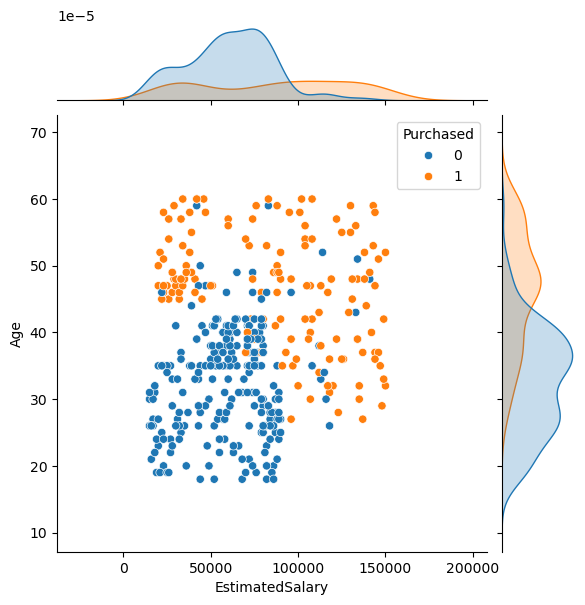

In [7]:
plt.figure
sns.jointplot(x='EstimatedSalary',y='Age',data=df,hue='Purchased')

# univariate analysis 

(array([19., 15., 31., 35., 22., 24., 64., 43., 35.,  9., 40., 17., 15.,
        11., 20.]),
 array([18. , 20.8, 23.6, 26.4, 29.2, 32. , 34.8, 37.6, 40.4, 43.2, 46. ,
        48.8, 51.6, 54.4, 57.2, 60. ]),
 <BarContainer object of 15 artists>)

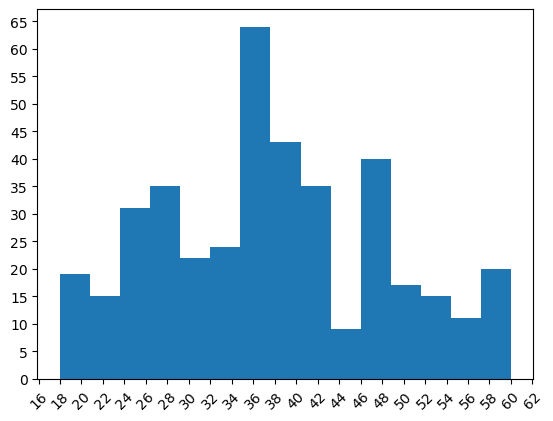

In [5]:
plt.xticks(range(0,70,2),rotation=45)  # used for changing the value on X axis
plt.yticks(range(0,80,5))              # used for changing the value of Y axis
plt.hist(df['Age'],bins=15)           # bins represent the how many no of bars you want

In [ ]:
# outlier => extreme value which is not following the crowd / away from others (introvert/isolated)

In [8]:
# Measures of Central Tendency => mean ,mode,median 
# Measures of Dispersion => Standard Deviation (SD),Variance,Range

In [9]:
ads=pd.read_csv("Social_Network_Ads.csv")
ads

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19.0,19000.0,0
1,15810944,Male,35.0,20000.0,0
2,15668575,Female,26.0,43000.0,0
3,15603246,Female,27.0,57000.0,0
4,15804002,Male,19.0,76000.0,0
...,...,...,...,...,...
395,15691863,Female,46.0,41000.0,1
396,15706071,Male,51.0,23000.0,1
397,15654296,Female,50.0,20000.0,1
398,15755018,Male,36.0,33000.0,0


In [10]:
# for the age col, on put the following values at that index 
# 2=> 8,3=> 85

In [11]:
ads.loc[2,'Age']=5
ads.loc[3,'Age']=85

{'whiskers': [<matplotlib.lines.Line2D at 0x27f5ddb79d0>,
 'caps': [<matplotlib.lines.Line2D at 0x27f5ddb7c50>,
 'boxes': [<matplotlib.lines.Line2D at 0x27f5ddb7890>],
 'medians': [<matplotlib.lines.Line2D at 0x27f5ddb7ed0>],
 'fliers': [<matplotlib.lines.Line2D at 0x27f5de14050>],
 'means': []}

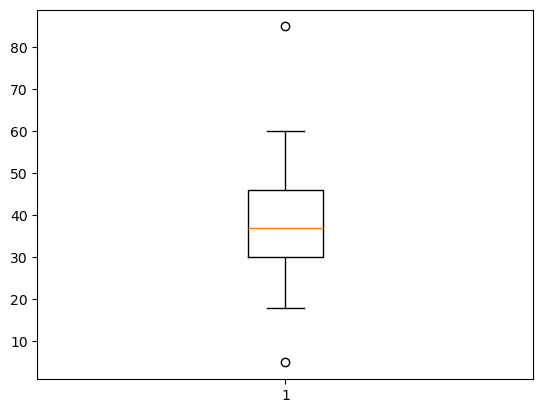

In [12]:
plt.boxplot(ads['Age']) # used to detect the outliers 

In [13]:
# create a function to remove outlier 

In [14]:
def rem_outliers(ads,column):
    Q1=ads[column].quantile(0.25)
    Q3=ads[column].quantile(0.75)
    IQR=Q3-Q1

    low_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR
    print("Q1:",Q1)
    print("Q3:",Q3)
    print("IQR:",IQR)
    print("lower bound:",low_bound)
    print("Upper bound:",upper_bound)

    return ads[
        (ads[column]>=low_bound) &
        (ads[column]<=upper_bound)]


In [15]:
outlier=rem_outliers(ads,'Age')

Q1: 30.0
Q3: 46.0
IQR: 16.0
lower bound: 6.0
Upper bound: 70.0


In [16]:
# load the tips dataset from seaborn
# do deatsiled EDA (charts along with explaination of what we are understanding from them )

In [17]:
import seaborn as sns
tips=sns.load_dataset('tips')

In [18]:
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [19]:
tips.shape # number of rows and columns
tips.info() # data type & memory usage
tips.describe # summary of numerical columns
tips.isnull().sum() # check the missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

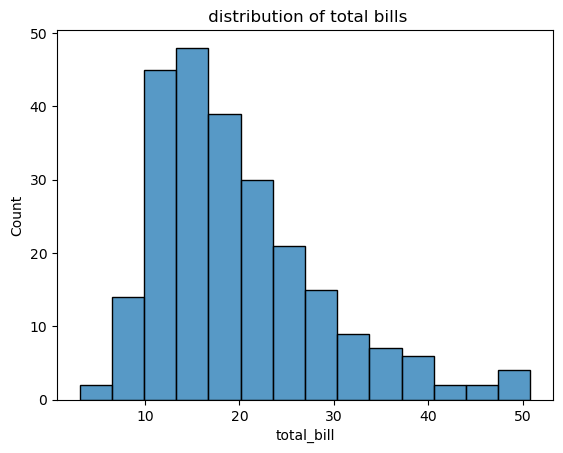

In [20]:
sns.histplot(tips['total_bill'])
plt.title(" distribution of total bills")
plt.show()

Text(0.5, 1.0, ' distribution of tip')

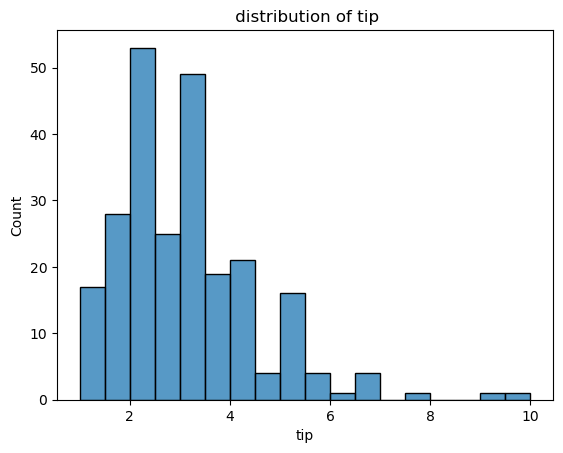

In [21]:
sns.histplot(tips['tip'])
plt.title(" distribution of tip")
# Most Tips Are Between 2 and 4
# There are few observations above $6
# Tips like 7, 8, 9, and 10 occur very uniquely 

<Axes: xlabel='total_bill', ylabel='tip'>

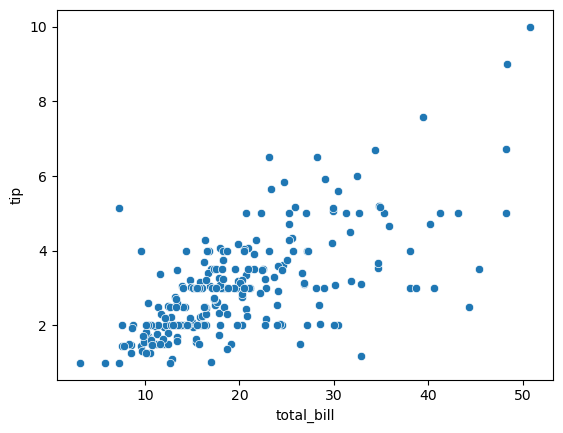

In [22]:
sns.scatterplot(data=tips,x='total_bill',y='tip')
# As the total bill increases, the tip generally increases.

# Bill $10 → Tip ≈ $1–2
# Bill $20 → Tip ≈ $2–4
# Bill $50 → Tip ≈ $5–10

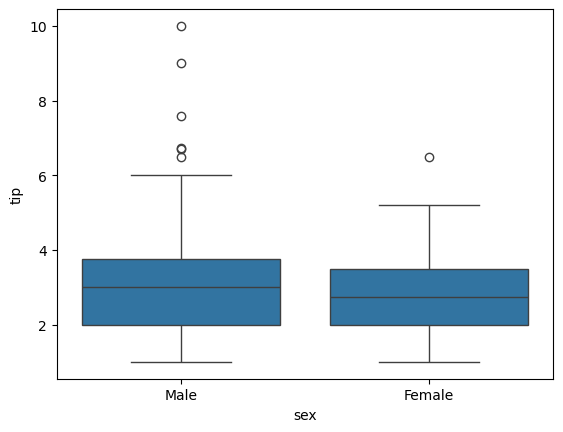

In [23]:
sns.boxplot(
    data=tips,
    x='sex',
    y='tip'
)
plt.show()

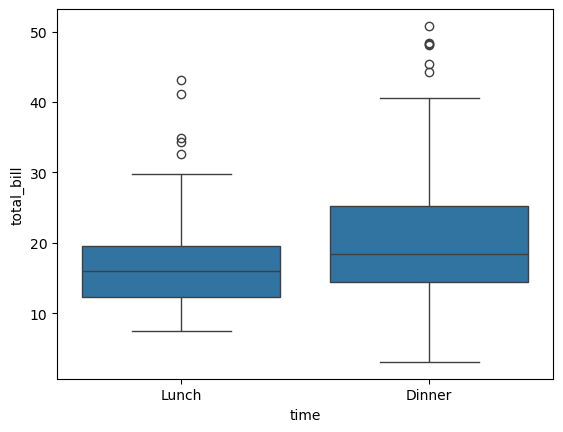

In [24]:
sns.boxplot(
    data=tips,
    x='time',
    y='total_bill'
)
plt.show()

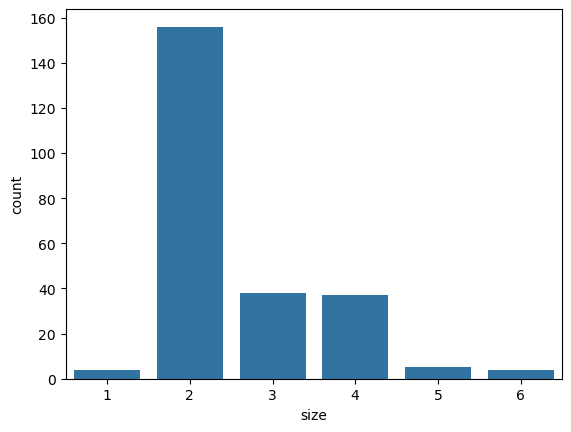

In [26]:
sns.countplot(
    data=tips,
    x='size'
)
plt.show()

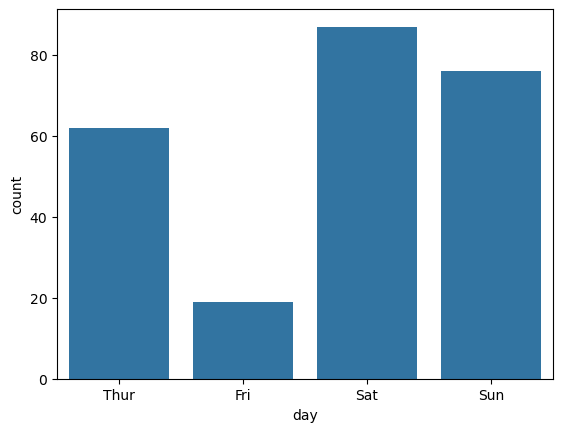

In [27]:
sns.countplot(
    data=tips,
    x='day'
)
plt.show()